In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from data_handling_raw import reshape_uyvy_to_yuv
import cv2
from matplotlib.patches import Rectangle

from data_handling_raw import BorderDataset, prepare_datasets_for_configs, prepare_dataset, adjust_brightness_contrast, rotate_image
from model_raw import ObstacleDetector
from utils_raw import EarlyStopping, TrainingMetrics, evaluate_model, save_checkpoint
from training_raw import train_with_cross_validation
from label_generator import cell_contains_bbox

import os
import json
from datetime import datetime
import traceback

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import onnxruntime as ort
import cv2
from glob import glob
import time

import matplotlib.pyplot as plt
import pandas as pd


In [9]:
def yuv_to_rgb(yuv_image):
    """
    Convert a YUV image to RGB using OpenCV.
    
    Args:
        yuv_image: (3, H, W) float32 array with Y, U, V channels.
    
    Returns:
        rgb_image: (H, W, 3) uint8 array with RGB channels.
    """
    # Transpose to (H, W, 3) for OpenCV
    yuv_image = yuv_image.transpose(1, 2, 0)
    
    # Scale Y channel to [0, 255] and U/V channels to [-128, 127]
    yuv_image[:, :, 0] *= 255  # Y channel
    yuv_image[:, :, 1:] = (yuv_image[:, :, 1:] * 255) - 128  # U and V channels
    
    # Convert to RGB
    rgb_image = cv2.cvtColor(yuv_image.astype(np.uint8), cv2.COLOR_YUV2RGB)
    
    return rgb_image

Sample image path: dataset_uyvy/images/100577924.raw
Sample label path: dataset_uyvy/labels/101311253.txt
Bounding boxes: [{'label': 1, 'x': 0.9552872062663185, 'y': 0.5, 'w': 0.08942558746736295, 'h': 0.9857484769364665}]
Raw data shape: (520, 480)
YUV image shape: (3, 260, 120)
RGB image shape: (260, 120, 3)


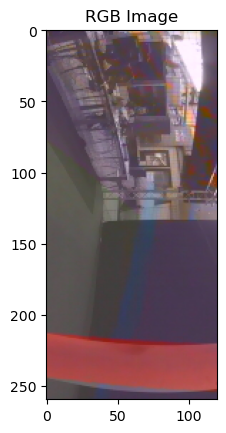

In [49]:

# Path to the dataset
dataset_dir = 'dataset_uyvy'
images_dir = os.path.join(dataset_dir, 'images')
# images_dir = 'front_images'
# images_dir = 'converted_raw_images'
labels_dir = os.path.join(dataset_dir, 'labels')

index = 5

# Load a sample image and its corresponding label
sample_image_path = os.path.join(images_dir, os.listdir(images_dir)[index])
sample_label_path = os.path.join(labels_dir, os.listdir(labels_dir)[index])

print("Sample image path:", sample_image_path)
print("Sample label path:", sample_label_path)

# Load the bounding box data
with open(sample_label_path, 'r') as f:
    bbox_data = f.read().strip().split('\n')

# Parse bounding box data
bboxes = []
if bbox_data:  # Check if the label file is not empty
    for line in bbox_data:
        parts = line.split()
        
        # Skip empty or malformed lines
        if len(parts) != 5:
            print(f"Skipping malformed line: {line}")
            continue
        
        try:
            bbox = {
                "label": int(parts[0]),  # Assuming the first value is the label
                "x": float(parts[1]),    # x-coordinate
                "y": float(parts[2]),    # y-coordinate
                "w": float(parts[3]),    # width
                "h": float(parts[4])     # height
            }
            bboxes.append(bbox)
        except (ValueError, IndexError) as e:
            print(f"Error parsing line: {line}. Error: {e}")
else:
    print("Label file is empty. No bounding boxes to process.")

# Print the bounding boxes
print("Bounding boxes:", bboxes)

# Load the raw UYVY image
with open(sample_image_path, 'rb') as f:
    raw_data = np.frombuffer(f.read(), dtype=np.uint8).reshape(520, 480)

# Verify raw data shape
print("Raw data shape:", raw_data.shape)  # Should be (520, 480)

# Convert UYVY to YUV
yuv_image = reshape_uyvy_to_yuv(raw_data, downscale_factor=2)

# Verify YUV image shape
print("YUV image shape:", yuv_image.shape)  # Should be (3, 260, 240)

# Convert YUV to RGB
rgb_image = yuv_to_rgb(yuv_image)

# Verify RGB image shape
print("RGB image shape:", rgb_image.shape)  # Should be (260, 240, 3)

# Plot the RGB image
plt.imshow(rgb_image)
plt.title("RGB Image")
plt.show()

# Set up grid lines
grid_lines = [[0, 0.2, 0.4, 0.6, 0.8, 1], [0, 1]]
grid_lines[0] = [line * 120 for line in grid_lines[0]]
grid_lines[1] = [line * 260 for line in grid_lines[1]]
danger_levels = 3